# Assignment 2 Debug Notebook

- 1단계: 환경과 데이터 로딩 확인
- 2단계: CIFAR-10용 ResNet50 모델 로딩
- 3단계: prediction disagreement 측정
- 4단계: neuron coverage 구현
- 5단계: DeepXplore식 입력 생성 실험


In [2]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import datasets, transforms

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'debug' else Path.cwd().resolve()
DATA_DIR = ROOT / 'data'
RESULTS_DIR = ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

print(f'root: {ROOT}')
print(f'device: {DEVICE}')
print(f'torch: {torch.__version__}')
print(f'cuda available: {torch.cuda.is_available()}')


root: /gpfs/home1/ahy0502/trustworthy-ai-assignment2
device: cuda
torch: 2.11.0+cu130
cuda available: True


## Step 1. Load CIFAR-10

우선 데이터셋 다운로드와 기본 전처리가 정상 동작하는지 확인
아직은 모델용 augmentation을 넣지 않고, 디버깅용으로 단순 `ToTensor()`만 사용


In [3]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck',
]

debug_transform = transforms.ToTensor()

test_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=debug_transform,
)

print(f'test samples: {len(test_dataset)}')
sample_img, sample_label = test_dataset[0]
print(f'sample shape: {tuple(sample_img.shape)}')
print(f'sample label: {sample_label} ({class_names[sample_label]})')
print(f'value range: [{sample_img.min().item():.4f}, {sample_img.max().item():.4f}]')


test samples: 10000
sample shape: (3, 32, 32)
sample label: 3 (cat)
value range: [0.0510, 1.0000]


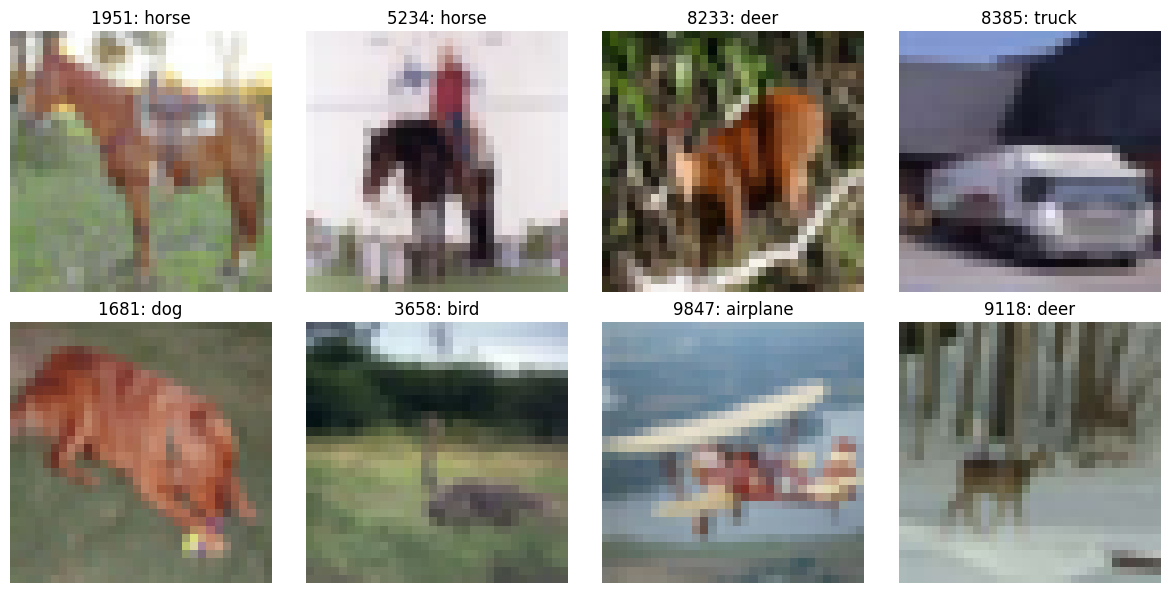

In [4]:
indices = random.sample(range(len(test_dataset)), 8)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, idx in zip(axes.flat, indices):
    image, label = test_dataset[idx]
    ax.imshow(image.permute(1, 2, 0).numpy())
    ax.set_title(f'{idx}: {class_names[label]}')
    ax.axis('off')

plt.tight_layout()
plt.show()


## Step 2. Build CIFAR-10 ResNet50 Models

과제 요구사항상 `CIFAR-10`에 대해 학습된 `ResNet50` 최소 2개가 필요함
우선은 학습 전 단계로, `CIFAR-10` 입력 크기에 맞는 `ResNet50` 구조를 직관적으로 정의하고 추론 shape가 정상인지 확인 단계 진행


In [5]:
from torch import nn
from torch.utils.data import DataLoader
from torchvision.models import resnet50
from tqdm.auto import tqdm

cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std = (0.2470, 0.2435, 0.2616)

model_input_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar10_mean, std=cifar10_std),
])

model_test_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=model_input_transform,
)

model_test_loader = DataLoader(
    model_test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

def build_cifar10_resnet50(random_seed):
    torch.manual_seed(random_seed)
    cifar10_resnet50_model = resnet50(weights=None)
    cifar10_resnet50_model.conv1 = nn.Conv2d(
        in_channels=3,
        out_channels=64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False,
    )
    cifar10_resnet50_model.maxpool = nn.Identity()
    cifar10_resnet50_model.fc = nn.Linear(
        in_features=cifar10_resnet50_model.fc.in_features,
        out_features=len(class_names),
    )
    return cifar10_resnet50_model.to(DEVICE)

model_random_seed_list = [2026, 2027]
model_name_list = ['resnet50_wo_aug', 'resnet50_w_aug']
resnet50_model_list = [build_cifar10_resnet50(seed) for seed in model_random_seed_list]

input_batch, label_batch = next(iter(model_test_loader))
input_batch = input_batch.to(DEVICE)

print(f'input batch shape: {tuple(input_batch.shape)}')
print(f'label batch shape: {tuple(label_batch.shape)}')

for model_name, resnet50_model in zip(model_name_list, resnet50_model_list):
    resnet50_model.eval()
    with torch.no_grad():
        output_logits = resnet50_model(input_batch)
    predicted_class_index_list = output_logits.argmax(dim=1)[:5].cpu().tolist()
    predicted_class_name_list = [class_names[index] for index in predicted_class_index_list]
    trainable_parameter_count = sum(parameter.numel() for parameter in resnet50_model.parameters())
    print(f'\n{model_name}')
    print(f'logits shape: {tuple(output_logits.shape)}')
    print(f'trainable parameter count: {trainable_parameter_count:,}')
    print(f'first 5 predicted classes: {predicted_class_name_list}')


/home1/ahy0502/miniconda3/envs/trustworthy-ai-a2/lib/python3.10/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/home1/ahy0502/miniconda3/envs/trustworthy-ai-a2/lib/python3.10/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.

input batch shape: (16, 3, 32, 32)
label batch shape: (16,)

resnet50_wo_aug
logits shape: (16, 10)
trainable parameter count: 23,520,842
first 5 predicted classes: ['deer', 'deer', 'deer', 'deer', 'deer']

resnet50_w_aug
logits shape: (16, 10)
trainable parameter count: 23,520,842
first 5 predicted classes: ['airplane', 'airplane', 'airplane', 'airplane', 'airplane']


## Step 3. Split Training Settings

최종 모델 차이는 `augmentation` 유무에서 만들 계획임
`test` preprocessing은 동일하게 유지하고, `train`에서는 한 모델은 augmentation 없이, 다른 모델은 augmentation을 적용하는 방향임


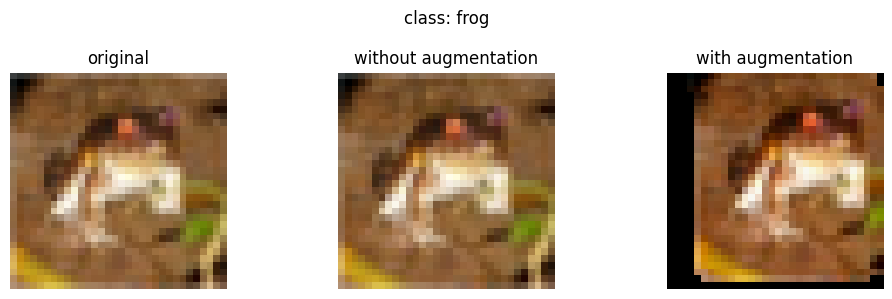

train samples without augmentation: 50000
train samples with augmentation: 50000
train batch shape without augmentation: (128, 3, 32, 32)
train batch shape with augmentation: (128, 3, 32, 32)
without augmentation vs with augmentation split ready


In [6]:
def unnormalize_image(normalized_image_tensor):
    mean_tensor = torch.tensor(cifar10_mean).view(3, 1, 1)
    std_tensor = torch.tensor(cifar10_std).view(3, 1, 1)
    restored_image_tensor = normalized_image_tensor.cpu() * std_tensor + mean_tensor
    return restored_image_tensor.clamp(0.0, 1.0)

train_transform_without_augmentation = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar10_mean, std=cifar10_std),
])

train_transform_with_augmentation = transforms.Compose([
    transforms.RandomCrop(size=32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.RandomRotation(degrees=12),
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar10_mean, std=cifar10_std),
])

train_dataset_without_augmentation = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=train_transform_without_augmentation,
)

train_dataset_with_augmentation = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=train_transform_with_augmentation,
)

train_loader_without_augmentation = DataLoader(
    train_dataset_without_augmentation,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

train_loader_with_augmentation = DataLoader(
    train_dataset_with_augmentation,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

raw_train_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transforms.ToTensor(),
)

sample_index = 0
original_image_tensor, original_label_index = raw_train_dataset[sample_index]
image_without_augmentation, _ = train_dataset_without_augmentation[sample_index]
image_with_augmentation, _ = train_dataset_with_augmentation[sample_index]

figure, axis_list = plt.subplots(1, 3, figsize=(10, 3))
axis_list[0].imshow(original_image_tensor.permute(1, 2, 0).numpy())
axis_list[0].set_title('original')
axis_list[1].imshow(unnormalize_image(image_without_augmentation).permute(1, 2, 0).numpy())
axis_list[1].set_title('without augmentation')
axis_list[2].imshow(unnormalize_image(image_with_augmentation).permute(1, 2, 0).numpy())
axis_list[2].set_title('with augmentation')

for axis in axis_list:
    axis.axis('off')

plt.suptitle(f'class: {class_names[original_label_index]}')
plt.tight_layout()
plt.show()

print(f'train samples without augmentation: {len(train_dataset_without_augmentation)}')
print(f'train samples with augmentation: {len(train_dataset_with_augmentation)}')

train_input_batch_without_augmentation, train_label_batch_without_augmentation = next(iter(train_loader_without_augmentation))
train_input_batch_with_augmentation, train_label_batch_with_augmentation = next(iter(train_loader_with_augmentation))

print(f'train batch shape without augmentation: {tuple(train_input_batch_without_augmentation.shape)}')
print(f'train batch shape with augmentation: {tuple(train_input_batch_with_augmentation.shape)}')
print('without augmentation vs with augmentation split ready')


## Step 4. Build Training Loop

두 모델을 공통 validation split으로 비교할 수 있게 학습 루프 구성 단계임
checkpoint 저장까지 연결하고, 기본값은 `run_training_now = False`로 두어 셀 실행 시 바로 장시간 학습이 시작되지 않게 설정 상태임


In [7]:
ckpts_dir = ROOT / 'ckpts'
ckpts_dir.mkdir(exist_ok=True)

validation_ratio = 0.1
training_epoch_count = 20
training_learning_rate = 0.1
training_momentum = 0.9
training_weight_decay = 5e-4
run_training_now = True

split_random_generator = torch.Generator().manual_seed(SEED)
all_train_index_tensor = torch.randperm(len(train_dataset_without_augmentation), generator=split_random_generator)
validation_sample_count = int(len(all_train_index_tensor) * validation_ratio)
validation_index_list = all_train_index_tensor[:validation_sample_count].tolist()
train_index_list = all_train_index_tensor[validation_sample_count:].tolist()

train_subset_without_augmentation = torch.utils.data.Subset(train_dataset_without_augmentation, train_index_list)
train_subset_with_augmentation = torch.utils.data.Subset(train_dataset_with_augmentation, train_index_list)

validation_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=model_input_transform,
)
validation_subset = torch.utils.data.Subset(validation_dataset, validation_index_list)

train_loader_wo_aug = DataLoader(
    train_subset_without_augmentation,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

train_loader_w_aug = DataLoader(
    train_subset_with_augmentation,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

validation_loader = DataLoader(
    validation_subset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

def calculate_accuracy(output_logits, label_index_tensor):
    predicted_label_index_tensor = output_logits.argmax(dim=1)
    correct_prediction_count = (predicted_label_index_tensor == label_index_tensor).sum().item()
    sample_count = label_index_tensor.size(0)
    return correct_prediction_count / sample_count

def train_one_epoch(model_name, resnet50_model, train_loader, loss_function, optimizer):
    resnet50_model.train()
    loss_sum = 0.0
    accuracy_sum = 0.0
    batch_count = 0

    train_progress_bar = tqdm(
        train_loader,
        desc=f'{model_name} train',
        leave=False,
        dynamic_ncols=True,
    )

    for input_batch, label_batch in train_progress_bar:
        input_batch = input_batch.to(DEVICE, non_blocking=torch.cuda.is_available())
        label_batch = label_batch.to(DEVICE, non_blocking=torch.cuda.is_available())

        optimizer.zero_grad()
        output_logits = resnet50_model(input_batch)
        loss_value = loss_function(output_logits, label_batch)
        loss_value.backward()
        optimizer.step()

        loss_sum += loss_value.item()
        accuracy_sum += calculate_accuracy(output_logits, label_batch)
        batch_count += 1
        train_progress_bar.set_postfix(
            loss=f'{loss_sum / batch_count:.4f}',
            acc=f'{accuracy_sum / batch_count:.4f}',
        )

    return loss_sum / batch_count, accuracy_sum / batch_count

def evaluate_model(model_name, resnet50_model, evaluation_loader, loss_function):
    resnet50_model.eval()
    loss_sum = 0.0
    accuracy_sum = 0.0
    batch_count = 0

    evaluation_progress_bar = tqdm(
        evaluation_loader,
        desc=f'{model_name} eval',
        leave=False,
        dynamic_ncols=True,
    )

    with torch.no_grad():
        for input_batch, label_batch in evaluation_progress_bar:
            input_batch = input_batch.to(DEVICE, non_blocking=torch.cuda.is_available())
            label_batch = label_batch.to(DEVICE, non_blocking=torch.cuda.is_available())

            output_logits = resnet50_model(input_batch)
            loss_value = loss_function(output_logits, label_batch)

            loss_sum += loss_value.item()
            accuracy_sum += calculate_accuracy(output_logits, label_batch)
            batch_count += 1
            evaluation_progress_bar.set_postfix(
                loss=f'{loss_sum / batch_count:.4f}',
                acc=f'{accuracy_sum / batch_count:.4f}',
            )

    return loss_sum / batch_count, accuracy_sum / batch_count

def train_model(model_name, resnet50_model, train_loader, validation_loader):
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(
        resnet50_model.parameters(),
        lr=training_learning_rate,
        momentum=training_momentum,
        weight_decay=training_weight_decay,
    )
    learning_rate_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=training_epoch_count,
    )
    ckpts_path = ckpts_dir / f'{model_name}.pt'
    training_history_list = []
    best_validation_accuracy = -1.0

    epoch_progress_bar = tqdm(
        range(training_epoch_count),
        desc=f'{model_name} epochs',
        leave=True,
        dynamic_ncols=True,
    )

    for epoch_index in epoch_progress_bar:
        train_loss, train_accuracy = train_one_epoch(
            model_name,
            resnet50_model,
            train_loader,
            loss_function,
            optimizer,
        )
        validation_loss, validation_accuracy = evaluate_model(
            model_name,
            resnet50_model,
            validation_loader,
            loss_function,
        )
        learning_rate_scheduler.step()

        epoch_result = {
            'epoch': epoch_index + 1,
            'train_loss': train_loss,
            'train_accuracy': train_accuracy,
            'validation_loss': validation_loss,
            'validation_accuracy': validation_accuracy,
        }
        training_history_list.append(epoch_result)
        epoch_progress_bar.set_postfix(
            train_loss=f'{train_loss:.4f}',
            train_acc=f'{train_accuracy:.4f}',
            val_loss=f'{validation_loss:.4f}',
            val_acc=f'{validation_accuracy:.4f}',
        )

        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy
            torch.save(
                {
                    'model_name': model_name,
                    'model_state_dict': resnet50_model.state_dict(),
                    'epoch': epoch_index + 1,
                    'validation_accuracy': validation_accuracy,
                },
                ckpts_path,
            )

        print(
            f"{model_name} | epoch {epoch_index + 1:02d}/{training_epoch_count} | "
            f"train loss {train_loss:.4f} | train acc {train_accuracy:.4f} | "
            f"val loss {validation_loss:.4f} | val acc {validation_accuracy:.4f}"
        )

    return training_history_list, ckpts_path

training_setup_list = [
    {
        'model_name': 'resnet50_wo_aug',
        'resnet50_model': resnet50_model_list[0],
        'train_loader': train_loader_wo_aug,
    },
    {
        'model_name': 'resnet50_w_aug',
        'resnet50_model': resnet50_model_list[1],
        'train_loader': train_loader_w_aug,
    },
]

print(f'train split size: {len(train_index_list)}')
print(f'validation split size: {len(validation_index_list)}')
print(f'ckpts dir: {ckpts_dir}')

if run_training_now:
    training_result_dict = {}
    for training_setup in training_setup_list:
        training_history_list, ckpts_path = train_model(
            model_name=training_setup['model_name'],
            resnet50_model=training_setup['resnet50_model'],
            train_loader=training_setup['train_loader'],
            validation_loader=validation_loader,
        )
        training_result_dict[training_setup['model_name']] = {
            'history': training_history_list,
            'ckpts_path': ckpts_path,
        }
else:
    print('training loop ready')
    print('set run_training_now = True to start training')


train split size: 45000
validation split size: 5000
ckpts dir: /gpfs/home1/ahy0502/trustworthy-ai-assignment2/ckpts


resnet50_wo_aug epochs:   0%|                                                                                 …

resnet50_wo_aug train:   0%|                                                                                  …

resnet50_wo_aug eval:   0%|                                                                                   …

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fde25e41480>
Traceback (most recent call last):
  File "/home1/ahy0502/miniconda3/envs/trustworthy-ai-a2/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/home1/ahy0502/miniconda3/envs/trustworthy-ai-a2/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/home1/ahy0502/miniconda3/envs/trustworthy-ai-a2/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process


...

resnet50_w_aug | epoch 19/20 | train loss 0.5565 | train acc 0.8042 | val loss 0.5129 | val acc 0.8206


resnet50_w_aug train:   0%|                                                                                   …

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fde25e41480>
Traceback (most recent call last):
  File "/home1/ahy0502/miniconda3/envs/trustworthy-ai-a2/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/home1/ahy0502/miniconda3/envs/trustworthy-ai-a2/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
<function _MultiProcessingDataLoaderIter.__del__ at 0x7fde25e41480>    
if w.is_alive():Traceback (most recent call last):

  File "/home1/ahy0502/miniconda3/envs/trustworthy-ai-a2/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/home1/ahy0502/miniconda3/envs/trustworthy-ai-a2/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
        self._shutdown_workers()assert self._parent_pid == os.getpid(), 'can only test a child process'

  File "/home1/ahy0502/miniconda3/envs/

resnet50_w_aug eval:   0%|                                                                                    …

resnet50_w_aug | epoch 20/20 | train loss 0.5278 | train acc 0.8134 | val loss 0.4978 | val acc 0.8279
